# Chapter 1, *Deep Learning for Biology*

In [26]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import linen as nn
import dlfb
from dlfb.utils.display import print_short_dict

## Some relevant Python

In [5]:
def compute_ten_power_sum(arr: jax.Array) -> float:
    """Raise values to the power of 10 and then sum."""
    return jnp.sum(arr**10)

jitted_compute_ten_power_sum = jax.jit(compute_ten_power_sum)

In [9]:
arr = jnp.array([1, 2, 3, 4, 5])
compute_ten_power_sum(arr)

Array(10874275, dtype=int32)

In [8]:

jitted_compute_ten_power_sum(arr)

Array(10874275, dtype=int32)

In [10]:
# closure example
def outer_fn(x):
    def inner_fn(y):
        return x + y
    return inner_fn
add_five = outer_fn(5) # return inner_fn with x = 5
result = add_five(10) # calculate inner_fn with x = 5 and y = 10
print(f"result: {result}")

result: 15


## JAX focus

In [11]:
rng = jax.random.PRNGKey(42)

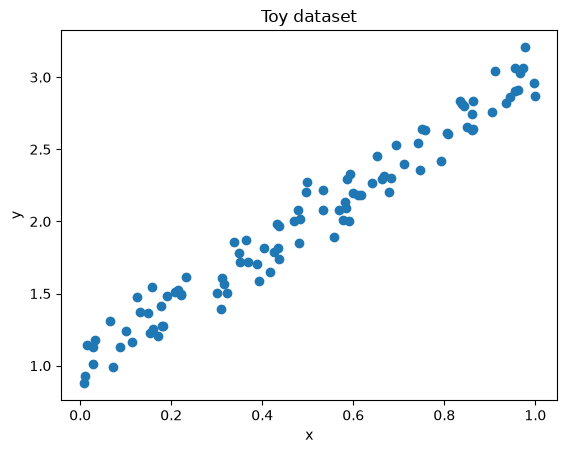

In [13]:
# create data
rng, rng_data, rng_noise = jax.random.split(rng, 3) # split into sub-keys due to lack of JAX hidden state
x_data = jax.random.uniform(rng_data, shape=(100, 1))
noise = .1 * jax.random.normal(rng_noise, shape=(100, 1))
y_data = 2 * x_data + 1 + noise

# visualize
plt.scatter(x_data, y_data)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy dataset")
plt.show()

## Flax focus

In [18]:
class LinearModel(nn.Module):
    @nn.compact # allows layers to be defined inside __call__()
    def __call__(self, x):
        return nn.Dense(features=1)(x)

In [19]:
model = LinearModel()

In [27]:
# initialize parameters
rng = jax.random.PRNGKey(42)
variables = model.init(rng, jnp.ones([1, 1]))
print_short_dict(variables)

{'params': {'Dense_0': {'kernel': Array([[-0.5220277]], dtype=float32), 'bias':
Array([0.], dtype=float32)}}}


In [29]:
import optax
from flax.training import train_state

In [32]:
# define adam optimzier with LR = 1.0
tx = optax.adam(1.0)

# create the training state
state = train_state.TrainState.create(
    apply_fn=model.apply, # forward pass fn
    params=variables["params"], # initialzed model params
    tx=tx, # transformation
)

# training state is immutable: each update returns a new TrainState with updated params

In [34]:
def calculate_loss(params, x, y):
    # forward pass of the model to get preds
    preds = model.apply({"parms": params}, x)

    # MSE loss
    return jnp.mean((predictions - y) ** 2)

In [35]:
@jax.jit
def train_step(state, x, y):
    # compute loss and gradients w.r.t. params
    loss, grads = jax.value_and_grad(compute_loss)(state.params, x, y)

    # apply grad updates
    new_state = state.apply_gradients(grads=grads)

    return new_state, loss

In [44]:
@jax.jit
def train_step_closure(state, x, y):
    def calculate_loss_inner(params):
        preds = state.apply_fn({"params": params}, x)
        return jnp.mean((preds - y) ** 2 ), preds
    (loss, preds), grads = jax.value_and_grad(calculate_loss_inner, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, (loss, preds)

In [46]:
num_epochs = 150
for epoch in range(num_epochs):
    state, (loss, _) = train_step_closure(state, x_data, y_data)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss: {loss:.4f}")

Epoch 0, loss: 0.0285
Epoch 10, loss: 0.0139
Epoch 20, loss: 0.0148
Epoch 30, loss: 0.0146
Epoch 40, loss: 0.0140
Epoch 50, loss: 0.0138
Epoch 60, loss: 0.0137
Epoch 70, loss: 0.0137
Epoch 80, loss: 0.0137
Epoch 90, loss: 0.0137
Epoch 100, loss: 0.0137
Epoch 110, loss: 0.0137
Epoch 120, loss: 0.0137
Epoch 130, loss: 0.0137
Epoch 140, loss: 0.0137


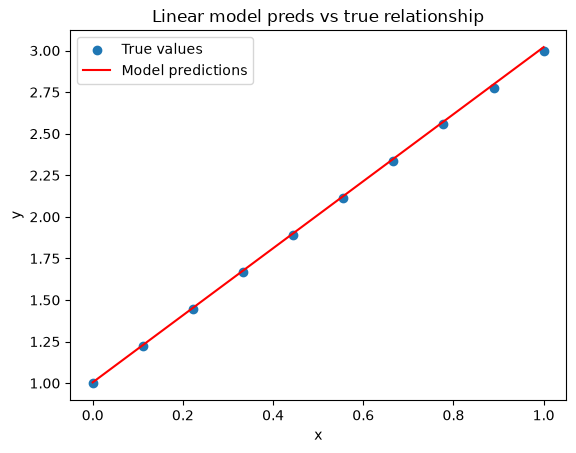

In [50]:
# test data
x_test = jnp.linspace(0, 1, 10).reshape(-1, 1)
y_test = 2 * x_test + 1

# get preds
y_pred = state.apply_fn({"params": state.params}, x_test)

# plot
plt.scatter(x_test, y_test, label="True values")
plt.plot(x_test, y_pred, color="red", label="Model predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Linear model preds vs true relationship")
plt.show()